# Looking at Different Performance Evaluation Metrics

While accuracy is a useful metric to quantify the overall performance of a model, there are several other performance metrics that can be used to measure a model's relevance, such as precision, recall, and the F1-score.

## 1. Reading a Confusion Matrix

A **confusion matrix** is a square matrix that reports the counts of the true positive (TP), true negative (TN), false positive (FP), and false negative (FN) predictions of a classifier.

* **True Positive (TP):** Correctly predicted positive class.
* **True Negative (TN):** Correctly predicted negative class.
* **False Positive (FP):** Incorrectly predicted positive class (Type I error).
* **False Negative (FN):** Incorrectly predicted negative class (Type II error).

### Implementation in scikit-learn

In [85]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


# 1. Read in the dataset directly from the UCI website using pandas
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data', header=None)

# 2. Assign features to X and labels to y, then encode labels
X = df.loc[:, 2:].values
y = df.loc[:, 1].values

le = LabelEncoder()
y = le.fit_transform(y)

print(le.transform(['M', 'B']))

# 3. Divide the dataset into training and test splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=1
)

# Create a pipeline with a standard scaler and SVM classifier
pipe_svc = make_pipeline(StandardScaler(), SVC(random_state=1))

[1 0]


[[71  1]
 [ 2 40]]


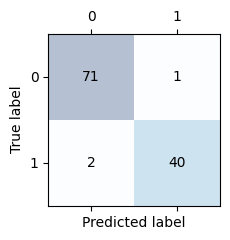

In [86]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Train the model and make predictions
pipe_svc.fit(X_train, y_train)
y_pred = pipe_svc.predict(X_test)

# Compute the confusion matrix
confmat = confusion_matrix(y_true=y_test, y_pred=y_pred)
print(confmat)

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(2.5, 2.5))
ax.matshow(confmat, cmap=plt.cm.Blues, alpha=0.3)
for i in range(confmat.shape[0]):
    for j in range(confmat.shape[1]):
        ax.text(x=j, y=i, s=confmat[i, j], va='center', ha='center')

plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
plt.show()

---

## 2. Optimizing Precision and Recall

Both the prediction error (ERR) and accuracy (ACC) provide general information about how many examples are misclassified.

$$ERR = \frac{FP + FN}{FP + FN + TP + TN}$$

$$ACC = \frac{TP + TN}{FP + FN + TP + TN} = 1 - ERR$$

However, for imbalanced datasets, we often want to look at more specific metrics:

* **True Positive Rate (TPR) / Recall:** Useful when minimizing false negatives is critical (e.g., medical diagnosis).

$$TPR = Recall = \frac{TP}{FN + TP}$$


* **False Positive Rate (FPR):**

$$FPR = \frac{FP}{FP + TN}$$


* **Precision (PRE):** Useful when minimizing false positives is critical.

$$PRE = \frac{TP}{TP + FP}$$


* **F1-Score:** The harmonic mean of precision and recall, providing a balanced metric.

$$F1 = 2 \times \frac{PRE \times Recall}{PRE + Recall}$$

### Implementation

In [87]:
from sklearn.metrics import precision_score, recall_score, f1_score

print(f'Precision: {precision_score(y_true=y_test, y_pred=y_pred):.3f}')
print(f'Recall: {recall_score(y_true=y_test, y_pred=y_pred):.3f}')
print(f'F1: {f1_score(y_true=y_test, y_pred=y_pred):.3f}')

Precision: 0.976
Recall: 0.952
F1: 0.964


Here is the summarized section on the **Matthews Correlation Coefficient (MCC)**, formatted to seamlessly append to your existing Colab notebook.

---

## 2.1. Matthews Correlation Coefficient (MCC)

When evaluating models on highly imbalanced datasets, metrics like precision, recall, and even the F1-score can sometimes be misleading because they primarily focus on the positive class and do not fully account for true negatives.

The **Matthews Correlation Coefficient (MCC)** is an alternative evaluation metric that is generally regarded as one of the most reliable measures for binary classification, especially for imbalanced datasets. It takes into account all four values of the confusion matrix (True Positives, True Negatives, False Positives, and False Negatives).

### The Formula

The MCC is essentially a correlation coefficient between the observed and predicted binary classifications:

$$MCC = \frac{TP \times TN - FP \times FN}{\sqrt{(TP + FP)(TP + FN)(TN + FP)(TN + FN)}}$$

### Interpreting the Score

The MCC returns a value between $-1$ and $+1$:

* **$MCC = 1$:** Represents a perfect prediction.
* **$MCC = 0$:** Represents a completely random prediction (the model is no better than flipping a coin).
* **$MCC = -1$:** Represents total disagreement between the prediction and the actual observation.

### Implementation in scikit-learn

Scikit-learn provides a built-in function to compute the MCC. We can calculate it directly from our true labels and predicted labels, or we can use it as a custom scoring metric during hyperparameter tuning.

In [88]:
from sklearn.metrics import matthews_corrcoef, make_scorer

# 1. Calculate MCC directly using test data predictions
mcc_score = matthews_corrcoef(y_true=y_test, y_pred=y_pred)
print(f'Matthews Correlation Coefficient (MCC): {mcc_score:.3f}')

# 2. Using MCC as the scoring metric in GridSearchCV
# First, convert the metric into a scorer
mcc_scorer = make_scorer(matthews_corrcoef)

# Initialize GridSearchCV with the custom MCC scorer
gs_mcc = GridSearchCV(estimator=pipe_svc,
                      param_grid=param_grid,
                      scoring=mcc_scorer,
                      cv=10,
                      n_jobs=-1)

# Fit the grid search to the training data
gs_mcc = gs_mcc.fit(X_train, y_train)

print(f'Best MCC score: {gs_mcc.best_score_:.3f}')
print(f'Best parameters (based on MCC): {gs_mcc.best_params_}')

Matthews Correlation Coefficient (MCC): 0.943
Best MCC score: 0.963
Best parameters (based on MCC): {'svc__C': 10.0, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}


### Custom Scoring in Grid Search

By default, `GridSearchCV` evaluates models using accuracy. You can change this to another metric (like the F1-score) using the `make_scorer` function.

In [89]:
from sklearn.metrics import make_scorer
from sklearn.model_selection import GridSearchCV

# Define the parameter range to test
c_gamma_range = [0.01, 0.1, 1.0, 10.0]

# Define the grid of parameters
param_grid = [
    {'svc__C': c_gamma_range, 'svc__kernel': ['linear']},
    {'svc__C': c_gamma_range, 'svc__gamma': c_gamma_range, 'svc__kernel': ['rbf']}
]

# Create a custom scorer for the F1 metric
scorer = make_scorer(f1_score, pos_label=0)

# Use the custom scorer in GridSearchCV
gs = GridSearchCV(estimator=pipe_svc,
                  param_grid=param_grid,
                  scoring=scorer,
                  cv=10)

gs = gs.fit(X_train, y_train)
print(f'Best F1 score: {gs.best_score_:.3f}')
print(f'Best parameters: {gs.best_params_}')

Best F1 score: 0.986
Best parameters: {'svc__C': 10.0, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}


---

## 3. Plotting a Receiver Operating Characteristic (ROC)

**Receiver Operating Characteristic (ROC)** graphs are useful tools to select models for classification based on their performance with respect to the False Positive Rate (FPR) and True Positive Rate (TPR).

* The diagonal of an ROC graph represents random guessing.
* A perfect classifier falls into the top-left corner (TPR = 1, FPR = 0).
* The **Area Under the Curve (AUC)** is used to summarize the performance in a single metric.

### Implementation

Here, we plot the ROC curve of a classifier by varying the prediction threshold. We will use a smaller feature subset (only features 4 and 14) to make the classification harder and the curve more interesting.

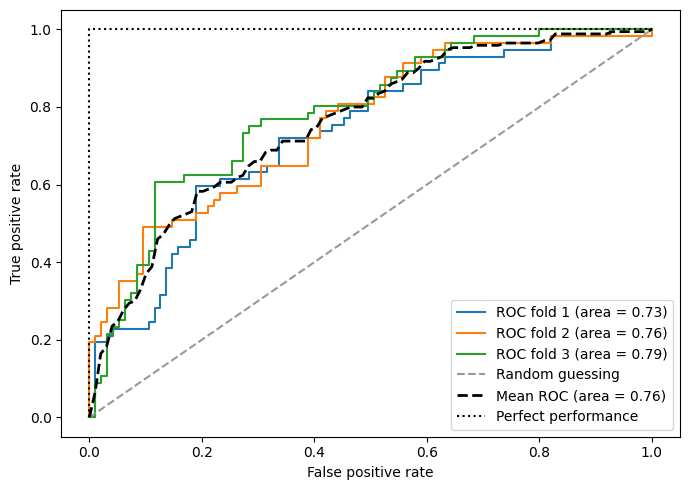

In [90]:
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import StratifiedKFold
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression


# Create a pipeline with PCA (2 components) and Logistic Regression
pipe_lr = make_pipeline(StandardScaler(),
                        PCA(n_components=2),
                        LogisticRegression(penalty='l2',
                                           random_state=1,
                                           solver='lbfgs',
                                           C=100.0))

# Select just two features to make the problem harder
X_train2 = X_train[:, [4, 14]]
cv = list(StratifiedKFold(n_splits=3).split(X_train2, y_train))

fig = plt.figure(figsize=(7, 5))
mean_tpr = 0.0
mean_fpr = np.linspace(0, 1, 100)
all_tpr = []

# Plot ROC for each fold
for i, (train, test) in enumerate(cv):
    probas = pipe_lr.fit(X_train2[train], y_train[train]).predict_proba(X_train2[test])
    fpr, tpr, thresholds = roc_curve(y_train[test], probas[:, 1], pos_label=1)

    mean_tpr += np.interp(mean_fpr, fpr, tpr)
    mean_tpr[0] = 0.0
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ROC fold {i+1} (area = {roc_auc:.2f})')

# Plot random guessing line
plt.plot([0, 1], [0, 1], linestyle='--', color=(0.6, 0.6, 0.6), label='Random guessing')

# Plot average ROC
mean_tpr /= len(cv)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
plt.plot(mean_fpr, mean_tpr, 'k--', label=f'Mean ROC (area = {mean_auc:.2f})', lw=2)

# Plot perfect performance line
plt.plot([0, 0, 1], [0, 1, 1], linestyle=':', color='black', label='Perfect performance')

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

---

## 4. Scoring Metrics for Multiclass Classification

The scoring metrics discussed above (precision, recall, F1) are specific to binary classification systems. However, we can extend them to multiclass problems via **One-vs-All (OvA)** classification.

We can aggregate these scores using either micro or macro averaging:

* **Micro-average:** Calculates metrics globally by counting the total true positives, false negatives, and false positives across all classes. Useful when you want to weight each *instance* or prediction equally.

$$PRE_{micro} = \frac{TP_1 + \dots + TP_k}{TP_1 + \dots + TP_k + FP_1 + \dots + FP_k}$$


* **Macro-average:** Calculates metrics for each class individually, then finds their unweighted mean. Useful when you want to evaluate the overall performance of a model with respect to the most frequent class labels, treating all *classes* equally regardless of class imbalances.

$$PRE_{macro} = \frac{PRE_1 + \dots + PRE_k}{k}$$



In scikit-learn, multiclass evaluation defaults to weighted macro-averaging, but you can explicitly specify the averaging method:

In [91]:
# Example of specifying macro or micro averaging for multiclass scoring
pre_scorer = make_scorer(score_func=precision_score,
                         pos_label=1,
                         greater_is_better=True,
                         average='micro')

## 5. Dealing with Class Imbalance

Class imbalance is a very common problem in real-world datasets, occurring when one or more classes are significantly underrepresented compared to others (e.g., spam filtering, fraud detection, or identifying rare diseases).

If a dataset has 90% benign tumors and 10% malignant tumors, a model could simply predict "benign" every single time and still achieve 90% accuracy, while entirely failing its true purpose.

To prevent models from being heavily biased toward the majority class, we can use several different techniques.

### Technique 1: Assigning Penalties (Class Weights)

The easiest way to deal with imbalanced classes is to assign a larger penalty to wrong predictions on the minority class. Most scikit-learn classifiers include a `class_weight` parameter for this exact purpose. Setting it to `'balanced'` automatically adjusts the weights inversely proportional to class frequencies in the training data.

In [92]:
from sklearn.svm import SVC

# The 'balanced' parameter automatically scales weights based on class distribution
svm = SVC(kernel='linear', C=1.0, class_weight='balanced', random_state=1)

# Fit the model as usual
svm.fit(X_train, y_train)

SVC(class_weight='balanced', kernel='linear', random_state=1)

### Technique 2: Upsampling the Minority Class

Another approach is to artificially balance the dataset by duplicating examples from the minority class until it matches the size of the majority class. We can do this using scikit-learn’s `resample` function.



In [93]:
# Create imbalanced dataset arrays
X_imb = np.vstack((X[y == 0], X[y == 1][:40]))
y_imb = np.hstack((y[y == 0], y[y == 1][:40]))

If we were to compute the accuracy of a model that always predicts the majority class (benign, class 0), we would achieve a prediction accuracy of approximately 90 percent:

In [94]:
y_pred = np.zeros(y_imb.shape[0])
np.mean(y_pred == y_imb) * 100

np.float64(89.92443324937027)

In [95]:
import numpy as np
from sklearn.utils import resample

# Let class 0 be the majority and class 1 be the minority
print(f'Initial class 1 count: {X_imb[y_imb == 1].shape[0]}')
print(f'Initial class 0 count: {X_imb[y_imb == 0].shape[0]}')

# Upsample the minority class (class 1)
X_upsampled, y_upsampled = resample(X_imb[y_imb == 1],
                                    y_imb[y_imb == 1],
                                    replace=True, # Sample with replacement
                                    n_samples=X_imb[y_imb == 0].shape[0], # Match majority class size
                                    random_state=123)

print(f'Upsampled class 1 count: {X_upsampled.shape[0]}')

# Combine the upsampled minority class with the original majority class
X_bal = np.vstack((X_imb[y_imb == 0], X_upsampled))
y_bal = np.hstack((y_imb[y_imb == 0], y_upsampled))

print(f'New balanced dataset shape: {X_bal.shape}')

Initial class 1 count: 40
Initial class 0 count: 357
Upsampled class 1 count: 357
New balanced dataset shape: (714, 30)


Consequently, a majority vote prediction rule would only achieve 50 percent accuracy:

In [96]:
y_pred = np.zeros(y_bal.shape[0])
np.mean(y_pred == y_bal) * 100

np.float64(50.0)

*(Note: Similarly, you could downsample the majority class by matching `n_samples` to the minority class size, though this risks losing valuable training information).*

### Technique 3: Synthetic Data Generation (SMOTE)

Instead of simply duplicating existing minority examples (which can lead to overfitting), you can generate new, synthetic examples using the **Synthetic Minority Over-sampling Technique (SMOTE)**.

SMOTE works by interpolating new points between existing minority examples. It is not native to scikit-learn, but it is available in the widely used `imbalanced-learn` library.

In [97]:
# Create imbalanced dataset arrays
X_imb = np.vstack((X[y == 0], X[y == 1][:40]))
y_imb = np.hstack((y[y == 0], y[y == 1][:40]))

In [98]:
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=1)

# Fit and apply the resampling to the dataset
X_smote, y_smote = smote.fit_resample(X_imb, y_imb)

print(f'Class distribution after SMOTE: {np.bincount(y_smote)}')

Class distribution after SMOTE: [357 357]
